# Tutorial 9: Utility Functions

This tutorial provides a hands-on tour of the utility functions in `brutus.utils`.
These functions underpin much of the core analysis in brutus but are also useful
on their own for photometric conversions, statistical computations, and posterior
sampling.

## Topics Covered

1. **Photometry conversions** -- magnitudes, luptitudes, and flux arithmetic
2. **Photometric likelihoods** -- standard and outlier models
3. **Mathematical utilities** -- matrix inversion, positive-definiteness checks, distribution functions
4. **Sampling utilities** -- weighted quantiles, multivariate normal sampling, posterior draws

## Prerequisites

This notebook requires **no external data files**. All demonstrations use
synthetic data generated on the fly.

In [1]:
# Setup: imports and plot style
import warnings

import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Tutorial utilities
from tutorial_utils import (
    setup_tutorial,
    save_figure,
    print_section,
    assert_array_properties,
)

# Run the standardized tutorial bootstrap
info = setup_tutorial(9, title="Tutorial 09: Utility Functions")

# Matplotlib defaults for this notebook
plt.rcParams["figure.figsize"] = (10, 6)


Tutorial 09: Utility Functions

Checking data requirements for Tutorial 9

  All required files available


## 1. Photometry Conversions

brutus works internally with **linear flux densities** rather than magnitudes.
The `brutus.utils` module provides functions for converting between the two
representations, as well as support for asinh magnitudes ("luptitudes") that
behave better at faint flux levels.

### Key functions

| Function | Description |
|---|---|
| `magnitude` | Flux to AB magnitude |
| `inv_magnitude` | AB magnitude to flux |
| `luptitude` | Flux to asinh magnitude (Lupton et al. 1999) |
| `inv_luptitude` | Asinh magnitude to flux |
| `add_mag` | Combine fluxes in magnitude space |
**Note on units:** brutus accepts photometry as linear flux densities
in native survey units -- specifically "maggies" (i.e., $10^{-0.4m}$
where $m$ is the magnitude in native survey units). The conversion
functions below (`magnitude`, `inv_magnitude`, etc.) handle the
transformation between magnitudes and this linear flux representation.

In [2]:
from brutus.utils import magnitude, inv_magnitude

print_section("1a. Magnitude / Flux Round-Trip")

# Create synthetic magnitude data: 5 objects, 4 filters
np.random.seed(42)
mag_orig = np.random.uniform(14, 22, size=(5, 4))
mag_err_orig = np.random.uniform(0.01, 0.1, size=(5, 4))

print("Original magnitudes (first object):")
print(f"  mag     = {mag_orig[0]}")
print(f"  mag_err = {mag_err_orig[0]}")

# Convert mag -> flux -> mag
flux, flux_err = inv_magnitude(mag_orig, mag_err_orig)
mag_recovered, mag_err_recovered = magnitude(flux, flux_err)

print("\nRecovered magnitudes (first object):")
print(f"  mag     = {mag_recovered[0]}")
print(f"  mag_err = {mag_err_recovered[0]}")

# Verify round-trip
mag_residual = np.max(np.abs(mag_orig - mag_recovered))
err_residual = np.max(np.abs(mag_err_orig - mag_err_recovered))
print(f"\nMax magnitude residual : {mag_residual:.2e}")
print(f"Max error residual    : {err_residual:.2e}")

assert np.allclose(mag_orig, mag_recovered, atol=1e-12), "Magnitude round-trip failed"
assert np.allclose(mag_err_orig, mag_err_recovered, atol=1e-12), "Error round-trip failed"
print("\nRound-trip verified: mag -> flux -> mag is exact.")


1a. Magnitude / Flux Round-Trip
Original magnitudes (first object):
  mag     = [16.99632095 21.60571445 19.85595153 18.78926787]
  mag_err = [0.06506676 0.02255445 0.03629302 0.04297257]

Recovered magnitudes (first object):
  mag     = [16.99632095 21.60571445 19.85595153 18.78926787]
  mag_err = [0.06506676 0.02255445 0.03629302 0.04297257]

Max magnitude residual : 3.55e-15
Max error residual    : 1.39e-17

Round-trip verified: mag -> flux -> mag is exact.


In [3]:
from brutus.utils import luptitude, inv_luptitude

print_section("1b. Luptitude (Asinh Magnitude) Round-Trip")

# Use the same synthetic flux data from above
skynoise = 1e-9  # softening parameter

# flux -> luptitude -> flux
lupt, lupt_err = luptitude(flux, flux_err, skynoise=skynoise)
flux_recovered, flux_err_recovered = inv_luptitude(lupt, lupt_err, skynoise=skynoise)

print("Original flux (first object):")
print(f"  flux     = {flux[0]}")
print(f"\nRecovered flux (first object):")
print(f"  flux     = {flux_recovered[0]}")

flux_residual = np.max(np.abs(flux - flux_recovered))
print(f"\nMax flux residual: {flux_residual:.2e}")

assert np.allclose(flux, flux_recovered, rtol=1e-10), "Luptitude round-trip failed"
print("Round-trip verified: flux -> luptitude -> flux is exact.")

# Compare magnitude vs luptitude for the same data
mag_from_flux, _ = magnitude(flux, flux_err)
print(f"\nMagnitude vs Luptitude (first object):")
print(f"  mag  = {mag_from_flux[0]}")
print(f"  lupt = {lupt[0]}")
print(f"  diff = {mag_from_flux[0] - lupt[0]}")
print("\nFor bright sources the two systems are nearly identical.")


1b. Luptitude (Asinh Magnitude) Round-Trip
Original flux (first object):
  flux     = [1.59027276e-07 2.27884202e-09 1.14187716e-08 3.04995092e-08]

Recovered flux (first object):
  flux     = [1.59027276e-07 2.27884202e-09 1.14187716e-08 3.04995092e-08]

Max flux residual: 2.12e-21
Round-trip verified: flux -> luptitude -> flux is exact.

Magnitude vs Luptitude (first object):
  mag  = [16.99632095 21.60571445 19.85595153 18.78926787]
  lupt = [16.99627802 21.43966326 19.84771879 18.78810257]
  diff = [4.29294498e-05 1.66051189e-01 8.23274868e-03 1.16530448e-03]

For bright sources the two systems are nearly identical.


In [4]:
from brutus.utils import add_mag

print_section("1c. Adding Magnitudes (Combining Fluxes)")

# Two equal-brightness stars: combined flux should be double,
# which is -2.5 * log10(2) ~ -0.75 mag brighter.
mag1 = np.array([15.0, 18.0, 20.0])
mag2 = np.array([15.0, 18.0, 20.0])

mag_combined = add_mag(mag1, mag2)

expected_shift = -2.5 * np.log10(2)
print(f"Two equal stars (mag = {mag1}):")
print(f"  Combined   = {mag_combined}")
print(f"  Expected   = {mag1 + expected_shift}")
print(f"  Shift      = {expected_shift:.4f} mag (= -2.5 * log10(2))")

assert np.allclose(mag_combined, mag1 + expected_shift, atol=1e-12)

# Unequal stars: 5-mag difference means 100x flux ratio
mag_a = np.array([15.0])
mag_b = np.array([20.0])
print(f"\nBright (mag=15) + faint (mag=20):")
print(f"  Combined = {add_mag(mag_a, mag_b)[0]:.4f} (barely changes the bright star)")


1c. Adding Magnitudes (Combining Fluxes)
Two equal stars (mag = [15. 18. 20.]):
  Combined   = [14.24742501 17.24742501 19.24742501]
  Expected   = [14.24742501 17.24742501 19.24742501]
  Shift      = -0.7526 mag (= -2.5 * log10(2))

Bright (mag=15) + faint (mag=20):
  Combined = 14.9892 (barely changes the bright star)



1d. Magnitude vs Luptitude at Faint Fluxes


  Saved: /home/user/brutus/tutorials/plots/tutorial_09/mag_vs_luptitude.png


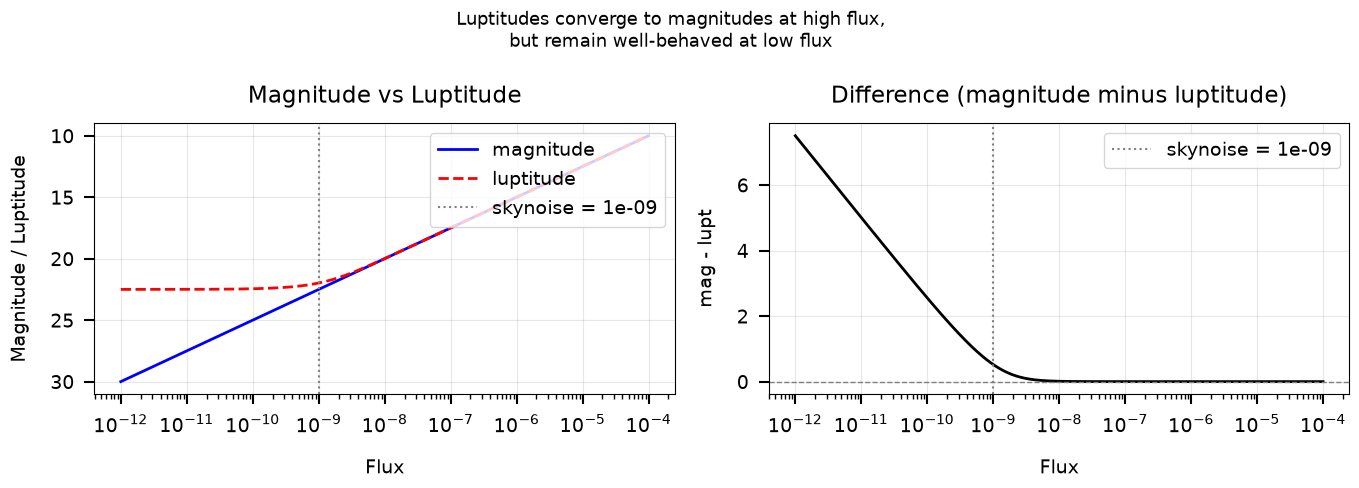

At bright fluxes the two systems agree to < 0.001 mag.
Near the sky noise level, luptitudes remain finite while magnitudes diverge.


In [5]:
print_section("1d. Magnitude vs Luptitude at Faint Fluxes")

# Demonstrate where luptitudes diverge from magnitudes
flux_range = np.logspace(-12, -4, 500).reshape(1, -1)  # shape (1, N) for API
flux_err_range = 0.1 * flux_range  # 10% errors

skynoise_demo = 1e-9

mag_vals, _ = magnitude(flux_range, flux_err_range)
lupt_vals, _ = luptitude(flux_range, flux_err_range, skynoise=skynoise_demo)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: magnitude and luptitude vs flux
ax = axes[0]
ax.plot(flux_range.ravel(), mag_vals.ravel(), "b-", lw=2, label="magnitude")
ax.plot(flux_range.ravel(), lupt_vals.ravel(), "r--", lw=2, label="luptitude")
ax.axvline(skynoise_demo, color="gray", ls=":", lw=1.5, label=f"skynoise = {skynoise_demo:.0e}")
ax.set_xscale("log")
ax.set_xlabel("Flux")
ax.set_ylabel("Magnitude / Luptitude")
ax.set_title("Magnitude vs Luptitude")
ax.legend(loc="upper right")
ax.invert_yaxis()
ax.grid(True, alpha=0.3)

# Right: difference
ax = axes[1]
diff = mag_vals.ravel() - lupt_vals.ravel()
ax.plot(flux_range.ravel(), diff, "k-", lw=2)
ax.axhline(0, color="gray", ls="--", lw=1)
ax.axvline(skynoise_demo, color="gray", ls=":", lw=1.5, label=f"skynoise = {skynoise_demo:.0e}")
ax.set_xscale("log")
ax.set_xlabel("Flux")
ax.set_ylabel("mag - lupt")
ax.set_title("Difference (magnitude minus luptitude)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle("Luptitudes converge to magnitudes at high flux,\n"
             "but remain well-behaved at low flux", fontsize=13)
save_figure(fig, 9, "mag_vs_luptitude")
plt.show()

print("At bright fluxes the two systems agree to < 0.001 mag.")
print("Near the sky noise level, luptitudes remain finite while magnitudes diverge.")

## 2. Photometric Likelihoods

The `phot_loglike` function computes the log-likelihood of observed photometry
given a set of model fluxes. Two additional functions provide outlier models:

| Function | Description |
|---|---|
| `phot_loglike` | Standard Gaussian photometric log-likelihood |
| `chisquare_outlier_loglike` | Chi-square based outlier model (for `dim_prior=True`) |
| `uniform_outlier_loglike` | Uniform-over-data-range outlier model (for `dim_prior=False`) |

**Note:** `uniform_outlier_loglike` returns a proper log *density* in flux
space (uniform over the observed flux range in each band, padded by
`sigma_clip` errors), so its value depends on the flux units and data range
and is directly comparable to the Gaussian inlier density.

In [6]:
from brutus.utils import phot_loglike
from brutus.utils.photometry import chisquare_outlier_loglike, uniform_outlier_loglike

print_section("2a. Photometric Log-Likelihood")

np.random.seed(123)

# One observed object with 5 filters
Nfilt = 5
true_flux = np.array([[1.0, 2.0, 3.0, 1.5, 0.8]])  # shape (1, 5)
obs_err = np.array([[0.1, 0.15, 0.2, 0.12, 0.08]])  # shape (1, 5)

# Create 100 model fluxes: good match, mediocre, and poor
Nmod = 100
# Models are spread around the truth with varying offsets
offsets = np.linspace(-1.5, 1.5, Nmod)
model_fluxes = true_flux[:, None, :] + offsets[None, :, None] * obs_err[:, None, :]
# shape: (1, 100, 5)

# Compute log-likelihoods
lnl = phot_loglike(true_flux, obs_err, model_fluxes)
lnl_dim = phot_loglike(true_flux, obs_err, model_fluxes, dim_prior=True)

print(f"Observed flux shape   : {true_flux.shape}")
print(f"Model flux shape      : {model_fluxes.shape}")
print(f"Log-likelihood shape  : {lnl.shape}")
print(f"\nBest log-likelihood (no dim_prior) : {lnl.max():.4f}")
print(f"Best log-likelihood (dim_prior)     : {lnl_dim.max():.4f}")

assert_array_properties(lnl, name="lnl", ndim=2, shape=(1, Nmod), finite=True)
print("\nLog-likelihood array properties verified.")


2a. Photometric Log-Likelihood
Observed flux shape   : (1, 5)
Model flux shape      : (1, 100, 5)
Log-likelihood shape  : (1, 100)

Best log-likelihood (no dim_prior) : 5.8599
Best log-likelihood (dim_prior)     : -1.8696

Log-likelihood array properties verified.


In [7]:
print_section("2b. Outlier Models")

# Compute outlier log-likelihoods for the observed object
lnl_chisq_outlier = chisquare_outlier_loglike(true_flux, obs_err)
lnl_uniform_outlier = uniform_outlier_loglike(true_flux, obs_err)

print(f"Chi-square outlier log-likelihood : {lnl_chisq_outlier[0]:.4f}")
print(f"Uniform outlier log-likelihood    : {lnl_uniform_outlier[0]:.4f}")
print(f"Best normal model log-likelihood  : {lnl.max():.4f}")

print("\nInterpretation:")
print("  If the best model lnl exceeds the outlier lnl, the object is well-fit.")
print("  If outlier lnl is higher, the object may be a contaminant or artifact.")

assert_array_properties(lnl_chisq_outlier, name="chisq_outlier", ndim=1, shape=(1,), finite=True)
assert_array_properties(lnl_uniform_outlier, name="uniform_outlier", ndim=1, shape=(1,), finite=True)
print("\nOutlier log-likelihood properties verified.")


2b. Outlier Models


Chi-square outlier log-likelihood : -12.3016
Uniform outlier log-likelihood    : 1.4963
Best normal model log-likelihood  : 5.8599

Interpretation:
  If the best model lnl exceeds the outlier lnl, the object is well-fit.
  If outlier lnl is higher, the object may be a contaminant or artifact.

Outlier log-likelihood properties verified.



2c. Likelihood Comparison Plot


  Saved: /home/user/brutus/tutorials/plots/tutorial_09/likelihood_comparison.png


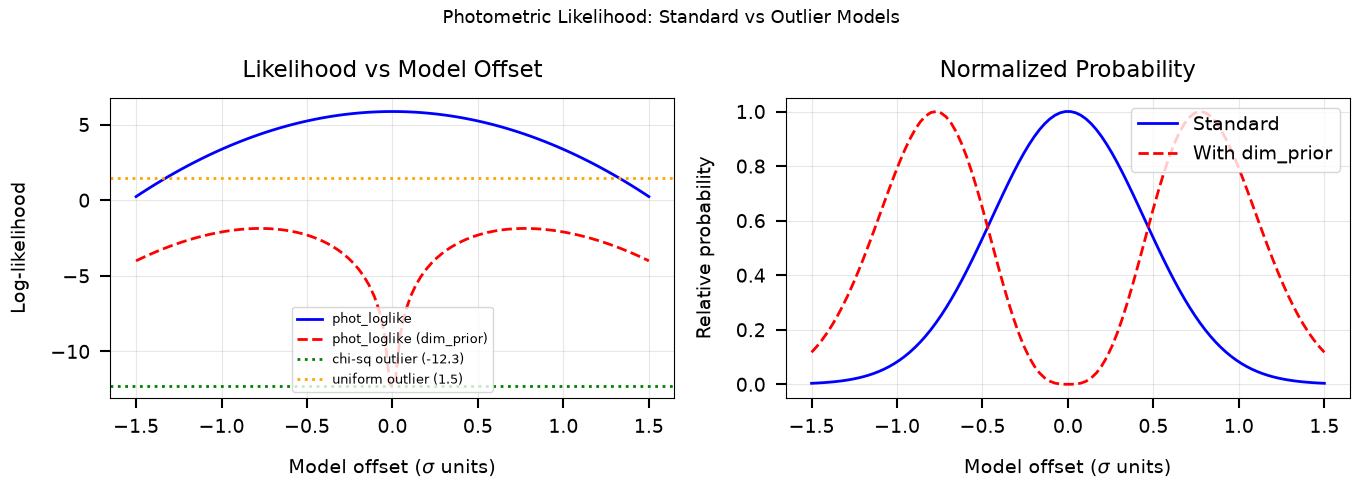

The standard likelihood peaks when model = data (offset = 0).
The dim_prior version additionally penalizes overfitting (too-perfect matches).


In [8]:
print_section("2c. Likelihood Comparison Plot")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: normal vs dim_prior likelihood curves
ax = axes[0]
ax.plot(offsets, lnl.ravel(), "b-", lw=2, label="phot_loglike")
ax.plot(offsets, lnl_dim.ravel(), "r--", lw=2, label="phot_loglike (dim_prior)")
ax.axhline(lnl_chisq_outlier[0], color="green", ls=":", lw=2,
           label=f"chi-sq outlier ({lnl_chisq_outlier[0]:.1f})")
ax.axhline(lnl_uniform_outlier[0], color="orange", ls=":", lw=2,
           label=f"uniform outlier ({lnl_uniform_outlier[0]:.1f})")
ax.set_xlabel(r"Model offset ($\sigma$ units)")
ax.set_ylabel("Log-likelihood")
ax.set_title("Likelihood vs Model Offset")
ax.legend(fontsize=9, loc="lower center")
ax.grid(True, alpha=0.3)

# Right: probability (exp-normalized)
ax = axes[1]
p_normal = np.exp(lnl.ravel() - lnl.max())
p_dim = np.exp(lnl_dim.ravel() - lnl_dim.max())

ax.plot(offsets, p_normal, "b-", lw=2, label="Standard")
ax.plot(offsets, p_dim, "r--", lw=2, label="With dim_prior")
ax.set_xlabel(r"Model offset ($\sigma$ units)")
ax.set_ylabel("Relative probability")
ax.set_title("Normalized Probability")
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle("Photometric Likelihood: Standard vs Outlier Models", fontsize=13)
save_figure(fig, 9, "likelihood_comparison")
plt.show()

print("The standard likelihood peaks when model = data (offset = 0).")
print("The dim_prior version additionally penalizes overfitting (too-perfect matches).")

## 3. Mathematical Utilities

The `brutus.utils` math module provides:

- Fast 3x3 matrix inversion optimized for covariance matrices (`inverse3`)
- Positive semi-definiteness check (`isPSD`)
- Chi-square log-PDF (`chisquare_logpdf`)
- Truncated normal PDF / log-PDF (`truncnorm_pdf`, `truncnorm_logpdf`)

In [9]:
from brutus.utils import inverse3, isPSD

print_section("3a. Fast 3x3 Matrix Inversion")

# Create a random positive-definite 3x3 matrix
np.random.seed(99)
L = np.array([[2.0, 0.0, 0.0],
              [0.5, 1.5, 0.0],
              [0.3, 0.2, 1.0]])
A = L @ L.T  # guaranteed positive-definite

print("Matrix A:")
print(A)

# Invert with brutus
A_inv = inverse3(A)

print("\nInverse A_inv:")
print(A_inv)

# Verify: A @ A_inv should be identity
product = A @ A_inv
print("\nA @ A_inv:")
print(product)

identity_error = np.max(np.abs(product - np.eye(3)))
print(f"\nMax deviation from identity: {identity_error:.2e}")

assert np.allclose(product, np.eye(3), atol=1e-10), "Inversion check failed"
print("Verification passed: A @ A_inv = I.")


3a. Fast 3x3 Matrix Inversion
Matrix A:
[[4.   1.   0.6 ]
 [1.   2.5  0.45]
 [0.6  0.45 1.13]]



Inverse A_inv:
[[ 0.29138889 -0.09555556 -0.11666667]
 [-0.09555556  0.46222222 -0.13333333]
 [-0.11666667 -0.13333333  1.        ]]

A @ A_inv:
[[ 1.00000000e+00 -1.36927506e-17 -8.88178420e-17]
 [ 4.25585493e-18  1.00000000e+00 -6.66133815e-17]
 [-2.42028619e-17 -1.43773882e-17  1.00000000e+00]]

Max deviation from identity: 8.88e-17
Verification passed: A @ A_inv = I.


In [10]:
print_section("3b. Positive Semi-Definiteness Check")

# Test 1: positive-definite matrix (from above)
print(f"A (positive-definite covariance):  isPSD = {isPSD(A)}")

# Test 2: identity matrix
I3 = np.eye(3)
print(f"Identity matrix:                   isPSD = {isPSD(I3)}")

# Test 3: zero matrix (positive semi-definite but not positive-definite)
Z3 = np.zeros((3, 3))
print(f"Zero matrix:                       isPSD = {isPSD(Z3)}")

# Test 4: matrix with a negative eigenvalue (NOT PSD)
bad_matrix = np.array([[1.0, 0.0, 0.0],
                       [0.0, -1.0, 0.0],
                       [0.0, 0.0, 1.0]])
print(f"Matrix with neg eigenvalue:        isPSD = {isPSD(bad_matrix)}")

# Test 5: non-symmetric matrix (NOT PSD by definition)
nonsym = np.array([[1.0, 2.0, 0.0],
                   [0.0, 1.0, 0.0],
                   [0.0, 0.0, 1.0]])
print(f"Non-symmetric matrix:              isPSD = {isPSD(nonsym)}")

assert isPSD(A), "PD matrix should be PSD"
assert not isPSD(bad_matrix), "Matrix with neg eigenvalue should not be PSD"
assert not isPSD(nonsym), "Non-symmetric matrix should not be PSD"
print("\nAll checks passed.")


3b. Positive Semi-Definiteness Check
A (positive-definite covariance):  isPSD = True
Identity matrix:                   isPSD = True
Zero matrix:                       isPSD = True
Matrix with neg eigenvalue:        isPSD = False
Non-symmetric matrix:              isPSD = False

All checks passed.



3c. Chi-Square Log-PDF


  Saved: /home/user/brutus/tutorials/plots/tutorial_09/chisquare_comparison.png


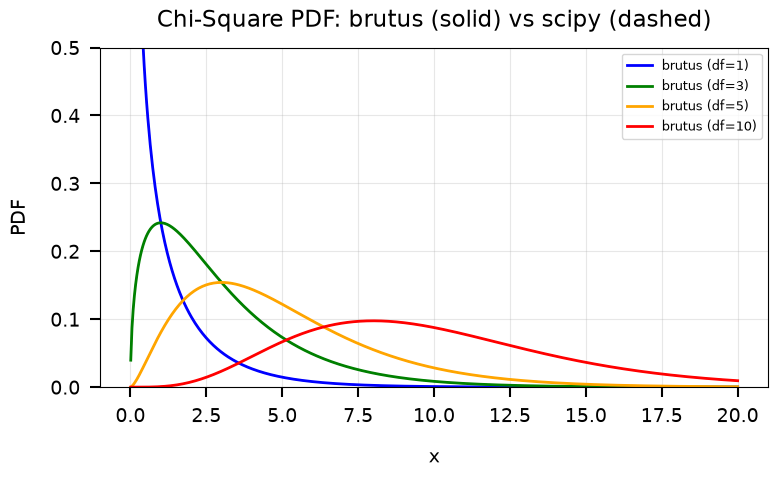

Max |log-PDF difference| for df=5: 1.78e-15
brutus and scipy chi-square log-PDFs agree to machine precision.


In [11]:
from brutus.utils import chisquare_logpdf
from scipy.stats import chi2 as scipy_chi2

print_section("3c. Chi-Square Log-PDF")

x = np.linspace(0.01, 20, 500)
dofs = [1, 3, 5, 10]

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

colors = ["blue", "green", "orange", "red"]
for df, color in zip(dofs, colors):
    logpdf_brutus = chisquare_logpdf(x, df=df)
    logpdf_scipy = scipy_chi2.logpdf(x, df=df)
    ax.plot(x, np.exp(logpdf_brutus), color=color, lw=2, label=f"brutus (df={df})")
    ax.plot(x, np.exp(logpdf_scipy), color=color, lw=1, ls="--", alpha=0.7)

ax.set_xlabel("x")
ax.set_ylabel("PDF")
ax.set_title("Chi-Square PDF: brutus (solid) vs scipy (dashed)")
ax.legend(fontsize=9)
ax.set_ylim(0, 0.5)
ax.grid(True, alpha=0.3)

save_figure(fig, 9, "chisquare_comparison")
plt.show()

# Numerical verification for df=5
logpdf_b = chisquare_logpdf(x, df=5)
logpdf_s = scipy_chi2.logpdf(x, df=5)
max_diff = np.max(np.abs(logpdf_b - logpdf_s))
print(f"Max |log-PDF difference| for df=5: {max_diff:.2e}")
assert max_diff < 1e-10, f"Chi-square implementations disagree: {max_diff}"
print("brutus and scipy chi-square log-PDFs agree to machine precision.")


3d. Truncated Normal Distribution


  Saved: /home/user/brutus/tutorials/plots/tutorial_09/truncnorm_comparison.png


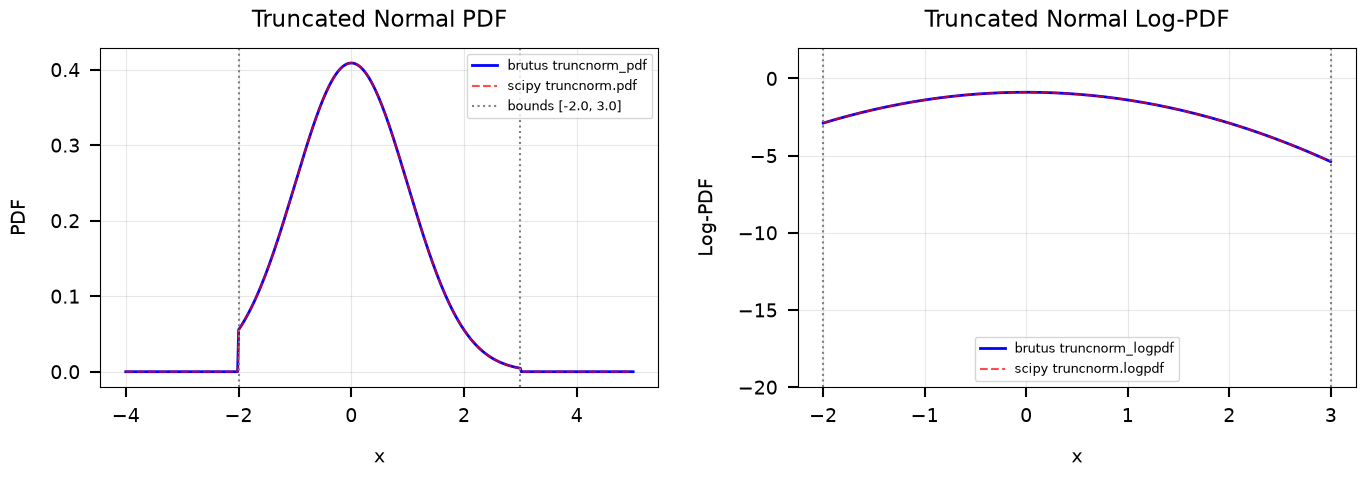

Max |PDF difference| in interior:     0.00e+00
Max |log-PDF difference| in interior: 0.00e+00
brutus and scipy truncated normal implementations agree.


In [12]:
from brutus.utils import truncnorm_pdf, truncnorm_logpdf
from scipy.stats import truncnorm as scipy_truncnorm

print_section("3d. Truncated Normal Distribution")

# Parameters: standard normal truncated to [-2, 3]
a, b = -2.0, 3.0
loc, scale = 0.0, 1.0

x = np.linspace(-4, 5, 500)

# brutus
pdf_brutus = truncnorm_pdf(x, a, b, loc=loc, scale=scale)
logpdf_brutus = truncnorm_logpdf(x, a, b, loc=loc, scale=scale)

# scipy (note: scipy uses standardized a, b limits)
a_std = (scale * a + loc - loc) / scale  # = a
b_std = (scale * b + loc - loc) / scale  # = b
pdf_scipy = scipy_truncnorm.pdf(x, a_std, b_std, loc=loc, scale=scale)
logpdf_scipy = scipy_truncnorm.logpdf(x, a_std, b_std, loc=loc, scale=scale)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: PDF comparison
ax = axes[0]
ax.plot(x, pdf_brutus, "b-", lw=2, label="brutus truncnorm_pdf")
ax.plot(x, pdf_scipy, "r--", lw=1.5, alpha=0.7, label="scipy truncnorm.pdf")
ax.axvline(scale * a + loc, color="gray", ls=":", lw=1.5, label=f"bounds [{scale*a+loc}, {scale*b+loc}]")
ax.axvline(scale * b + loc, color="gray", ls=":", lw=1.5)
ax.set_xlabel("x")
ax.set_ylabel("PDF")
ax.set_title("Truncated Normal PDF")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right: log-PDF comparison
ax = axes[1]
ax.plot(x, logpdf_brutus, "b-", lw=2, label="brutus truncnorm_logpdf")
ax.plot(x, logpdf_scipy, "r--", lw=1.5, alpha=0.7, label="scipy truncnorm.logpdf")
ax.axvline(scale * a + loc, color="gray", ls=":", lw=1.5)
ax.axvline(scale * b + loc, color="gray", ls=":", lw=1.5)
ax.set_xlabel("x")
ax.set_ylabel("Log-PDF")
ax.set_title("Truncated Normal Log-PDF")
ax.set_ylim(-20, 2)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

save_figure(fig, 9, "truncnorm_comparison")
plt.show()

# Verify in the interior of the support
interior = (x > scale * a + loc + 0.01) & (x < scale * b + loc - 0.01)
max_pdf_diff = np.max(np.abs(pdf_brutus[interior] - pdf_scipy[interior]))
max_logpdf_diff = np.max(np.abs(logpdf_brutus[interior] - logpdf_scipy[interior]))

print(f"Max |PDF difference| in interior:     {max_pdf_diff:.2e}")
print(f"Max |log-PDF difference| in interior: {max_logpdf_diff:.2e}")
assert max_pdf_diff < 1e-10, f"Truncated normal PDF mismatch: {max_pdf_diff}"
assert max_logpdf_diff < 1e-10, f"Truncated normal log-PDF mismatch: {max_logpdf_diff}"
print("brutus and scipy truncated normal implementations agree.")

## 4. Sampling Utilities

These functions are used for posterior analysis after fitting:

| Function | Description |
|---|---|
| `quantile` | Compute (weighted) quantiles from samples |
| `sample_multivariate_normal` | Draw from multiple multivariate normals simultaneously |
| `draw_sar` | Draw from joint (scale, A_V, R_V) posterior |

In [13]:
from brutus.utils import quantile

print_section("4a. Weighted Quantiles")

np.random.seed(77)

# Unweighted case
samples = np.sort(np.random.normal(5.0, 1.5, size=10000))
q_values = np.array([0.16, 0.50, 0.84])
q_unw = quantile(samples, q_values)

print("Unweighted samples (N=10000, mean=5, std=1.5):")
print(f"  16th percentile : {q_unw[0]:.3f}  (expected ~{5.0 - 1.5:.1f})")
print(f"  50th percentile : {q_unw[1]:.3f}  (expected ~5.0)")
print(f"  84th percentile : {q_unw[2]:.3f}  (expected ~{5.0 + 1.5:.1f})")

# Weighted case: heavily weight the upper tail
weights = np.where(samples > 6.0, 10.0, 1.0)
q_wt = quantile(samples, q_values, weights=weights)

print("\nWeighted samples (10x weight for samples > 6):")
print(f"  16th percentile : {q_wt[0]:.3f}")
print(f"  50th percentile : {q_wt[1]:.3f}")
print(f"  84th percentile : {q_wt[2]:.3f}")
print(f"\nWeighted median shifted from {q_unw[1]:.3f} to {q_wt[1]:.3f} (toward high values).")

assert_array_properties(q_unw, name="quantiles_unw", ndim=1, shape=(3,), finite=True)
assert_array_properties(q_wt, name="quantiles_wt", ndim=1, shape=(3,), finite=True)
assert q_wt[1] > q_unw[1], "Weighted median should be larger"
print("Quantile computations verified.")


4a. Weighted Quantiles
Unweighted samples (N=10000, mean=5, std=1.5):
  16th percentile : 3.492  (expected ~3.5)
  50th percentile : 4.982  (expected ~5.0)
  84th percentile : 6.506  (expected ~6.5)

Weighted samples (10x weight for samples > 6):
  16th percentile : 5.077
  50th percentile : 6.482
  84th percentile : 7.480

Weighted median shifted from 4.982 to 6.482 (toward high values).
Quantile computations verified.



4b. Multivariate Normal Sampling
Mean: [ 3. -1.]
Covariance:
[[1.  0.6]
 [0.6 0.5]]
isPSD(cov) = True

Samples shape: (2, 2000)  (dim, size)

Sample mean: [ 2.98417272 -1.00011614]  (expected: [ 3. -1.])
Sample cov:
[[0.9792843  0.57710111]
 [0.57710111 0.48133874]]
(expected:
[[1.  0.6]
 [0.6 0.5]])


  Saved: /home/user/brutus/tutorials/plots/tutorial_09/mvn_samples.png


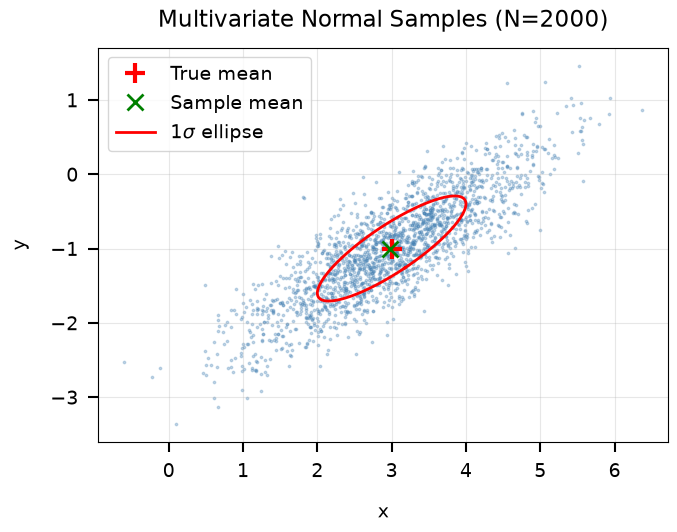

Sample distribution matches the specified mean and covariance.


In [14]:
from brutus.utils import sample_multivariate_normal

print_section("4b. Multivariate Normal Sampling")

np.random.seed(42)

# Define a 2D distribution with correlation
mean = np.array([3.0, -1.0])
cov = np.array([[1.0, 0.6],
                [0.6, 0.5]])

print(f"Mean: {mean}")
print(f"Covariance:\n{cov}")
print(f"isPSD(cov) = {isPSD(cov)}")

# Draw 2000 samples from a single distribution
Nsamples = 2000
samples_2d = sample_multivariate_normal(mean, cov, size=Nsamples)
print(f"\nSamples shape: {samples_2d.shape}  (dim, size)")

# Verify sample statistics
sample_mean = samples_2d.mean(axis=1)
sample_cov = np.cov(samples_2d)
print(f"\nSample mean: {sample_mean}  (expected: {mean})")
print(f"Sample cov:\n{sample_cov}")
print(f"(expected:\n{cov})")

assert_array_properties(samples_2d, name="mvn_samples", ndim=2, shape=(2, Nsamples), finite=True)

# Plot
fig, ax = plt.subplots(1, 1, figsize=(7, 6))
ax.scatter(samples_2d[0], samples_2d[1], s=3, alpha=0.3, color="steelblue")
ax.plot(mean[0], mean[1], "r+", markersize=15, mew=3, label="True mean")
ax.plot(sample_mean[0], sample_mean[1], "gx", markersize=12, mew=2, label="Sample mean")

# Draw 1-sigma ellipse
theta = np.linspace(0, 2 * np.pi, 200)
eigvals, eigvecs = np.linalg.eigh(cov)
circle = np.column_stack([np.cos(theta), np.sin(theta)])
ellipse = circle @ np.diag(np.sqrt(eigvals)) @ eigvecs.T + mean
ax.plot(ellipse[:, 0], ellipse[:, 1], "r-", lw=2, label=r"1$\sigma$ ellipse")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"Multivariate Normal Samples (N={Nsamples})")
ax.legend()
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)

save_figure(fig, 9, "mvn_samples")
plt.show()

print("Sample distribution matches the specified mean and covariance.")

### 4c. Scale Factor, Distance, and Extinction

The `draw_sar` function draws correlated samples of **(scale, A_V, R_V)**
from the joint posterior at each model grid point. Understanding the
**scale factor** is key to interpreting these draws:

- **Scale** represents the squared ratio of reference distance to true distance:
  `scale = (d_ref / d)^2 = 1 / d_kpc^2` (since `d_ref = 1 kpc` in brutus).
- To convert a scale draw to a distance: `d_kpc = 1 / sqrt(scale)`.
- Larger scale values correspond to *closer* objects; smaller scale values
  correspond to more *distant* objects.

Note that brutus now samples in **log-distance space** rather than
scale-space in the main fitting pipeline. Log-distance sampling provides
better importance sampling behavior, especially for distant or faint
sources where the posterior in scale-space becomes highly skewed.
The `draw_sar` utility remains available for cases where you need
correlated (scale, A_V, R_V) draws from the per-model covariance
matrices stored in BruteForce output.

**What to look for in the plots below:** The correlated (scale, A_V, R_V)
draws illustrate how distance and extinction trade off -- objects that
are inferred to be closer (higher scale) tend to require less foreground
extinction (lower A_V), and vice versa. The R_V draws show the additional
uncertainty in the shape of the extinction curve.


4c. Drawing from (Scale, A_V, R_V) Posterior
Input parameters:
  Model 0: scale=1.00, A_V=0.50, R_V=3.32
  Model 1: scale=0.80, A_V=1.00, R_V=3.30
  Model 2: scale=1.20, A_V=2.00, R_V=2.80

Draw shapes: scale=(3, 500), A_V=(3, 500), R_V=(3, 500)
All draws within specified bounds (A_V: [0, 6], R_V: [1, 8]).


  Saved: /home/user/brutus/tutorials/plots/tutorial_09/draw_sar.png


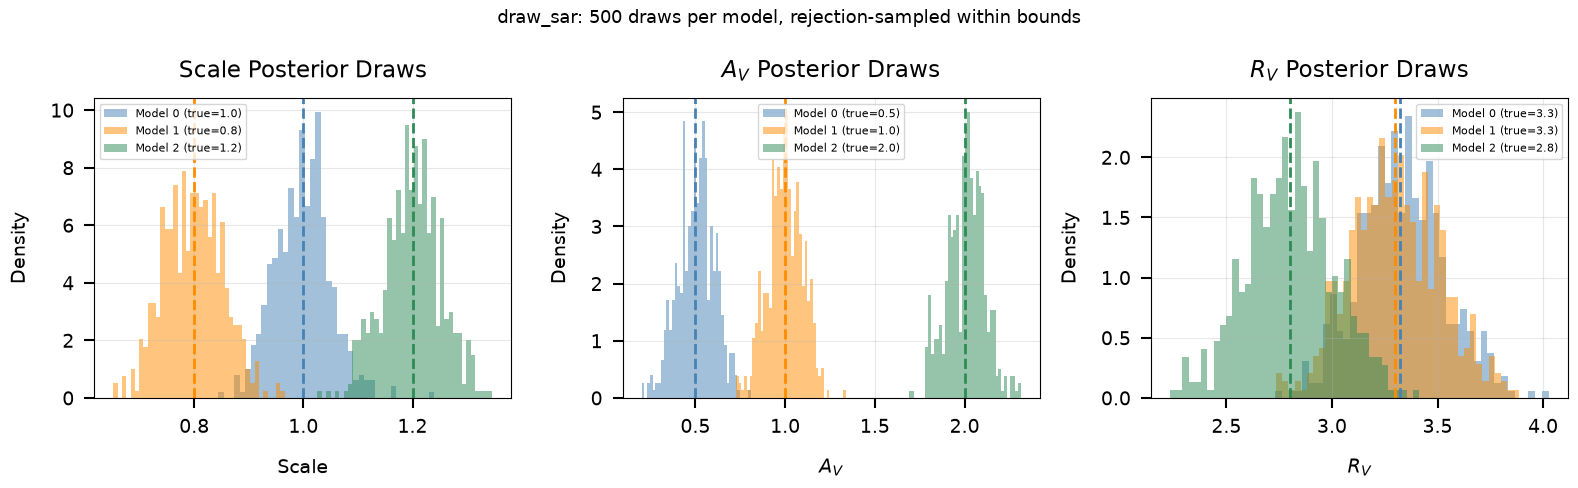

Draws are centered on input values and respect physical bounds.


In [15]:
from brutus.utils import draw_sar

print_section("4c. Drawing from (Scale, A_V, R_V) Posterior")

np.random.seed(55)

# Simulate posterior parameters for 3 model grid points
Nsamps = 3
scales = np.array([1.0, 0.8, 1.2])     # scale factors
avs = np.array([0.5, 1.0, 2.0])        # A_V values
rvs = np.array([3.32, 3.3, 2.8])        # R_V values

# Covariance matrices (3x3 each)
covs_sar = np.zeros((Nsamps, 3, 3))
for i in range(Nsamps):
    L = np.diag([0.05, 0.1, 0.2])  # diagonal Cholesky factor
    L[1, 0] = 0.02  # small s-Av correlation
    L[2, 0] = 0.01  # small s-Rv correlation
    L[2, 1] = 0.05  # Av-Rv correlation
    covs_sar[i] = L @ L.T

print("Input parameters:")
for i in range(Nsamps):
    print(f"  Model {i}: scale={scales[i]:.2f}, A_V={avs[i]:.2f}, R_V={rvs[i]:.2f}")

# Generate draws
ndraws = 500
sdraws, adraws, rdraws = draw_sar(
    scales, avs, rvs, covs_sar, ndraws=ndraws,
    avlim=(0.0, 6.0), rvlim=(1.0, 8.0)
)

print(f"\nDraw shapes: scale={sdraws.shape}, A_V={adraws.shape}, R_V={rdraws.shape}")

assert_array_properties(sdraws, name="scale_draws", ndim=2, shape=(Nsamps, ndraws), finite=True)
assert_array_properties(adraws, name="av_draws", ndim=2, shape=(Nsamps, ndraws), finite=True,
                        min_val=0.0, max_val=6.0)
assert_array_properties(rdraws, name="rv_draws", ndim=2, shape=(Nsamps, ndraws), finite=True,
                        min_val=1.0, max_val=8.0)
print("All draws within specified bounds (A_V: [0, 6], R_V: [1, 8]).")

# Plot the draws
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

param_names = ["Scale", r"$A_V$", r"$R_V$"]
draw_arrays = [sdraws, adraws, rdraws]
true_vals = [scales, avs, rvs]
colors = ["steelblue", "darkorange", "seagreen"]

for col, (ax, pname, draws, trues) in enumerate(
    zip(axes, param_names, draw_arrays, true_vals)
):
    for i in range(Nsamps):
        ax.hist(draws[i], bins=40, alpha=0.5, density=True,
                color=colors[i], label=f"Model {i} (true={trues[i]:.1f})")
        ax.axvline(trues[i], color=colors[i], ls="--", lw=2)
    ax.set_xlabel(pname)
    ax.set_ylabel("Density")
    ax.set_title(f"{pname} Posterior Draws")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(f"draw_sar: {ndraws} draws per model, rejection-sampled within bounds",
             fontsize=13)
save_figure(fig, 9, "draw_sar")
plt.show()

print("Draws are centered on input values and respect physical bounds.")

## Summary

This tutorial demonstrated the utility functions available in `brutus.utils`:

### Photometry Conversions (Section 1)

- `magnitude` / `inv_magnitude` provide exact round-trip conversion between flux and AB magnitudes.
- `luptitude` / `inv_luptitude` provide asinh magnitudes that remain well-behaved at faint fluxes where standard magnitudes diverge.
- `add_mag` combines fluxes expressed as magnitudes.

### Photometric Likelihoods (Section 2)

- `phot_loglike` is the core likelihood function used in BruteForce fitting. The optional `dim_prior` flag adds a chi-square dimensionality penalty.
- `chisquare_outlier_loglike` and `uniform_outlier_loglike` provide baseline log-likelihoods for identifying outlier objects that no stellar model can fit.

### Mathematical Utilities (Section 3)

- `inverse3` provides fast, numba-accelerated 3x3 matrix inversion optimized for covariance matrices.
- `isPSD` checks whether a matrix is positive semi-definite, which is required for valid covariance matrices.
- `chisquare_logpdf` and `truncnorm_pdf` / `truncnorm_logpdf` replicate scipy distributions with lightweight implementations.

### Sampling Utilities (Section 4)

- `quantile` computes weighted quantiles from posterior samples, essential for credible intervals.
- `sample_multivariate_normal` draws from many multivariate normal distributions simultaneously using Cholesky decomposition.
- `draw_sar` generates rejection-sampled posterior draws for (scale, A_V, R_V) within physical bounds.

### Next Steps

These utilities are used throughout the brutus fitting pipeline. See:

- **Tutorial 5** for how `phot_loglike` drives the BruteForce fitter
- **Tutorial 6** for how `draw_sar` and `quantile` appear in cluster analysis
- **Tutorial 8** for how photometric offsets interact with magnitude conversions